# Gestion des outliers de prix (french-second-hand-cars)

Le RMSE (~12k€) est gonflé par une petite queue de voitures très chères. On mesure l'effet
de **3 stratégies** de gestion des outliers, seuil réglable **`SEUIL`** (par défaut 50 000 €).

- **A. Tout garder** — référence.
- **B. Winsoriser** — plafonner le prix du train au seuil (garde toutes les lignes).
- **C. Restreindre le scope** — n'entraîner que sur les voitures ≤ seuil (marché grand public, cible OscarIA).

> ⚠️ **Piège** : comparer le R² entre des jeux de test différents n'a pas de sens (retirer les
> voitures chères baisse la variance → le R² change tout seul). On évalue donc les 3 stratégies
> sur le **même test = le marché courant (≤ seuil)** : « qui prédit le mieux le grand public ? »

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

SEUIL = 50_000      # >>> RÉGLAGE : seuil de coupure/plafond en euros (ex: 60_000) <<<

df = clean_cars("../../data/french-second-hand-cars/raw/French_second_hand_cars.csv")
df = add_brand_features(df, load_premium_table("../../references/premium_brand.csv"))
print("shape:", df.shape)

shape: (2340, 51)


## 1. Analyse de la queue de prix

/var/folders/3l/v1pvxhld5873jqqxvwq3r_w00000gn/T/ipykernel_10961/2135067713.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(p, vert=False); ax[1].axvline(SEUIL, color="r", ls="--"); ax[1].set_title("prix — boxplot")


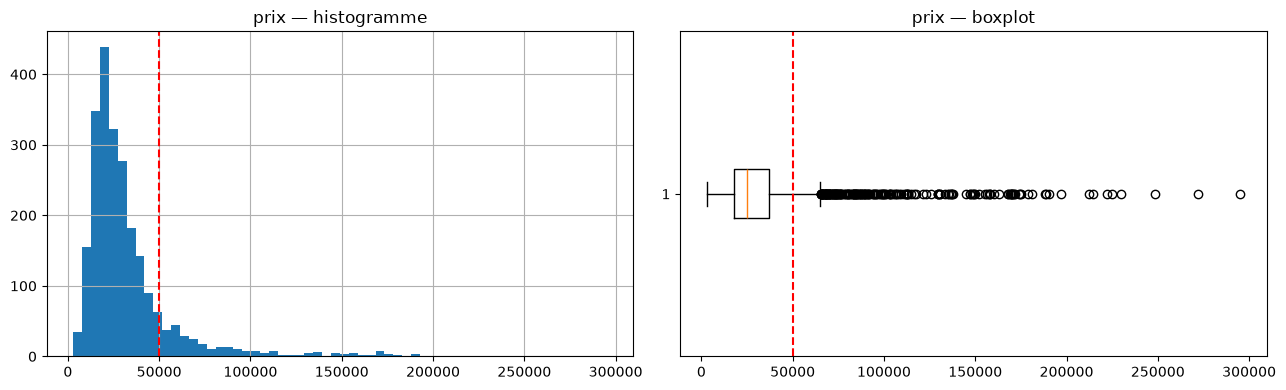

percentiles: {'p90': 58729, 'p95': 83432, 'p99': 169325}

> 50,000 € : 308 voitures (13.2%)
paliers de ces voitures: {'premium': 157, 'luxe': 100, 'generaliste': 51}


In [2]:
p = df["price"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
p.hist(bins=60, ax=ax[0]); ax[0].axvline(SEUIL, color="r", ls="--"); ax[0].set_title("prix — histogramme")
ax[1].boxplot(p, vert=False); ax[1].axvline(SEUIL, color="r", ls="--"); ax[1].set_title("prix — boxplot")
plt.tight_layout(); plt.show()

print("percentiles:", {f"p{q}": round(p.quantile(q/100)) for q in [90,95,99]})
au_dessus = df[df["price"] > SEUIL]
print(f"\n> {SEUIL:,} € : {len(au_dessus)} voitures ({len(au_dessus)/len(df)*100:.1f}%)")
print("paliers de ces voitures:", au_dessus["palier"].value_counts().to_dict())

## 2. Split unique + base d'évaluation commune

Même découpage pour toutes les stratégies. Le **test d'évaluation commun** = les voitures
du test dont le prix réel est ≤ seuil (le marché qu'OscarIA vise).

In [3]:
features = ["age", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces",
            "niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]

data = df[features + ["price"]].dropna(subset=["price"])
X, y = data[features], data["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# base commune : marché courant (<= seuil) dans le test
mask_eval = y_test <= SEUIL
X_eval, y_eval = X_test[mask_eval], y_test[mask_eval]
print(f"test complet: {len(y_test)} | base commune ≤{SEUIL//1000}k: {len(y_eval)}")

test complet: 468 | base commune ≤50k: 402


## 3. Les 3 stratégies (même modèle, seul le TRAIN change)

In [4]:
def modele():
    # HistGradientBoosting en log-cible (meilleur du notebook 3)
    return TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(random_state=42),
        func=np.log1p, inverse_func=np.expm1)

def scores(model, Xe, ye, nom):
    pred = model.predict(Xe)
    return {"stratégie": nom,
            "MAE (€)": round(mean_absolute_error(ye, pred)),
            "RMSE (€)": round(np.sqrt(mean_squared_error(ye, pred))),
            "R²": round(r2_score(ye, pred), 3)}

lignes = []

# A. tout garder
mA = modele().fit(X_train, y_train)

# B. winsoriser le prix du train à SEUIL (toutes les lignes gardées)
mB = modele().fit(X_train, y_train.clip(upper=SEUIL))

# C. restreindre le train aux voitures <= SEUIL
mask_train = y_train <= SEUIL
mC = modele().fit(X_train[mask_train], y_train[mask_train])
print("train A:", len(y_train), "| B:", len(y_train), "(prix plafonné) | C:", int(mask_train.sum()))

train A: 1872 | B: 1872 (prix plafonné) | C: 1630


## 4. Comparaison — sur la base commune (marché ≤ seuil)

C'est la comparaison **équitable** : même jeu de test pour les 3.

In [5]:
commune = pd.DataFrame([
    scores(mA, X_eval, y_eval, f"A. tout garder"),
    scores(mB, X_eval, y_eval, f"B. winsorize {SEUIL//1000}k"),
    scores(mC, X_eval, y_eval, f"C. scope ≤{SEUIL//1000}k"),
])
commune

,stratégie,MAE (€),RMSE (€),R²
0,A. tout garder,3397,4941,0.775
1,B. winsorize 50k,3139,4333,0.827
2,C. scope ≤50k,3213,4450,0.818


## 5. À titre indicatif — sur le test complet (avec le luxe)

**Non comparable** au tableau précédent (jeu de test différent), mais montre ce que chaque
stratégie donne si on veut *aussi* couvrir le haut de gamme.

In [6]:
complet = pd.DataFrame([
    scores(mA, X_test, y_test, f"A. tout garder"),
    scores(mB, X_test, y_test, f"B. winsorize {SEUIL//1000}k"),
    scores(mC, X_test, y_test, f"C. scope ≤{SEUIL//1000}k"),
])
complet

,stratégie,MAE (€),RMSE (€),R²
0,A. tout garder,5444,11972,0.844
1,B. winsorize 50k,8917,23855,0.379
2,C. scope ≤50k,9263,24114,0.366


## 6. Réel vs prédit — marché courant (meilleure stratégie sur base commune)

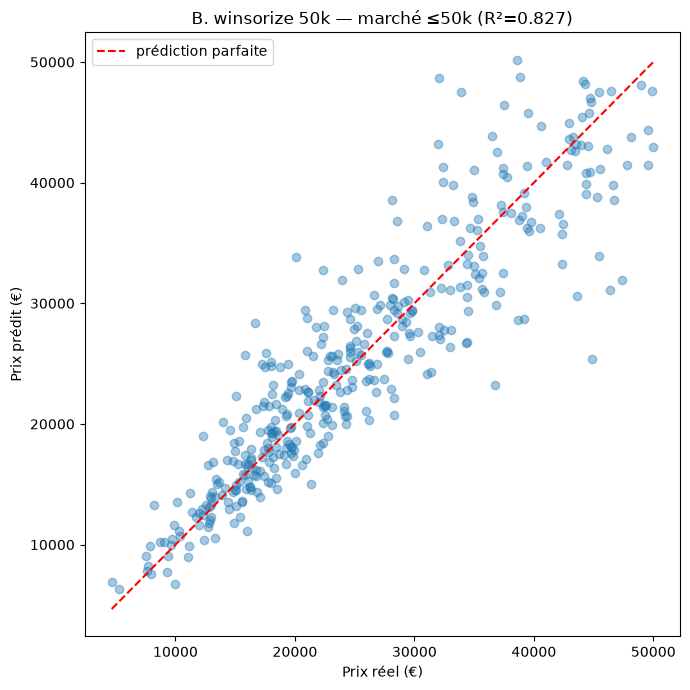

In [7]:
best_name = commune.sort_values("MAE (€)").iloc[0]["stratégie"]
best = {f"A. tout garder": mA, f"B. winsorize {SEUIL//1000}k": mB, f"C. scope ≤{SEUIL//1000}k": mC}[best_name]
pred = best.predict(X_eval)

plt.figure(figsize=(7,7))
plt.scatter(y_eval, pred, alpha=0.4)
lims = [y_eval.min(), y_eval.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
plt.title(f"{best_name} — marché ≤{SEUIL//1000}k (R²={r2_score(y_eval, pred):.3f})")
plt.legend(); plt.tight_layout(); plt.show()

## Lecture (BC04)

- Sur le **marché courant (≤ seuil)** — la cible d'OscarIA — B et C réduisent l'influence des
  voitures de luxe pendant l'entraînement et améliorent (ou égalent) la prédiction du grand public.
- **Restreindre le scope (C)** = choix produit **légitime mais à documenter** : le modèle ne
  couvre plus l'exotique. Honnêteté sur les limites = attendu BC04.
- **Winsoriser (B)** garde toutes les données mais **biaise le très haut de gamme** (tout ce qui
  dépasse le seuil est écrasé au seuil) — à éviter si on veut un jour couvrir le premium.
- Le tableau « test complet » rappelle qu'aucune stratégie n'est magique sur le luxe : trop peu
  d'exemples, trop de variance.
- **Prochaine étape produit** : passer au prix en **fourchette + incertitude** (exigence OscarIA), non traité.